<a href="https://colab.research.google.com/github/vishalbansal05/IP_Lab_Assignments/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

Saving Add-stars-and-clouds-to-sky-photography-online-using-a-free-photo-editor.jpg to Add-stars-and-clouds-to-sky-photography-online-using-a-free-photo-editor.jpg
Original image shape: (685, 1370, 3)


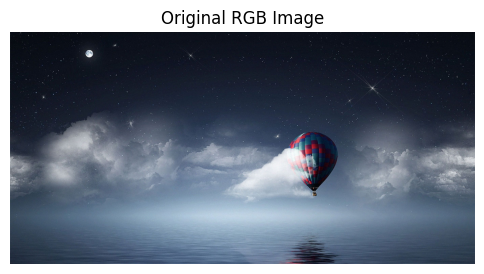

In [2]:
uploaded = files.upload()

image_filename = list(uploaded.keys())[0]

img_rgb = Image.open(io.BytesIO(uploaded[image_filename])).convert('RGB')

img_array = np.array(img_rgb)

print(f"Original image shape: {img_array.shape}")

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title('Original RGB Image')
plt.axis('off')
plt.show()

### Case 1: Grayscale Conversion by Mean Average

In this method, each pixel's grayscale value is calculated by taking the simple arithmetic mean of its Red, Green, and Blue components. The formula is: `Gray = (R + G + B) / 3`.

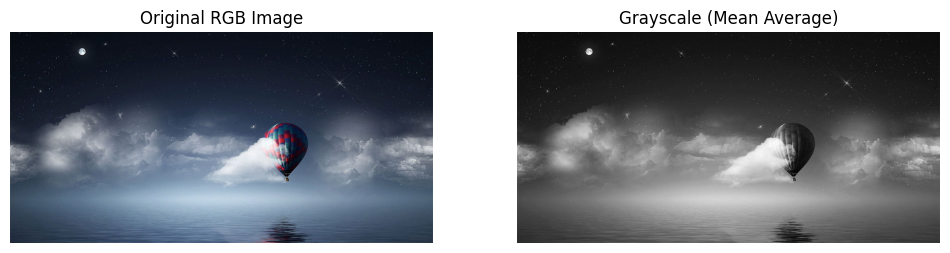

In [3]:
img_gray_mean = np.mean(img_array, axis=2).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gray_mean, cmap='gray')
plt.title('Grayscale (Mean Average)')
plt.axis('off')

plt.show()

Enter weightage for Red (0-1): 0.66
Enter weightage for Green (0-1): 0.66
Enter weightage for Blue (0-1): 0.66
The sum of weights (1.98) is not equal to 1. Please try again.
Enter weightage for Red (0-1): 0.33
Enter weightage for Green (0-1): 0.33
Enter weightage for Blue (0-1): 0.33
The sum of weights (0.99) is not equal to 1. Please try again.
Enter weightage for Red (0-1): 0.33
Enter weightage for Green (0-1): 0.33
Enter weightage for Blue (0-1): 0.34
Using weights: R=0.33, G=0.33, B=0.34


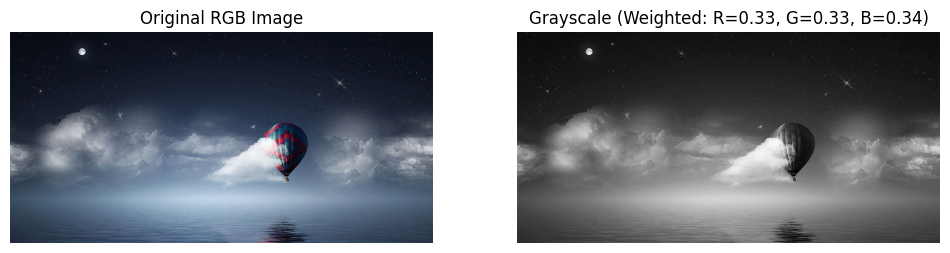

In [4]:
def get_weight(color_name):
    while True:
        try:
            weight = float(input(f"Enter weightage for {color_name} (0-1): "))
            if 0 <= weight <= 1:
                return weight
            else:
                print("Weightage must be between 0 and 1. Please try again.")
        except ValueError:
            print("Invalid input. Please enter a number.")

while True:
    weight_r = get_weight('Red')
    weight_g = get_weight('Green')
    weight_b = get_weight('Blue')

    if abs(weight_r + weight_g + weight_b - 1.0) < 1e-6:
        break
    else:
        print(f"The sum of weights ({weight_r + weight_g + weight_b:.2f}) is not equal to 1. Please try again.")

print(f"Using weights: R={weight_r}, G={weight_g}, B={weight_b}")

img_gray_weighted = (weight_r * img_array[:,:,0] + \
                     weight_g * img_array[:,:,1] + \
                     weight_b * img_array[:,:,2]).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gray_weighted, cmap='gray')
plt.title(f'Grayscale (Weighted: R={weight_r}, G={weight_g}, B={weight_b})')
plt.axis('off')

plt.show()